In this notebook, I want to try to include different soil types. 

In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem,
    create_matrix, 
    create_vector, 
)
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    sqrt,
    ln,
    lhs,
    rhs,
    conditional,
    derivative,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import *

In [2]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

2026-04-30 14:50:03.361 (   0.544s) [    73E86CD63600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


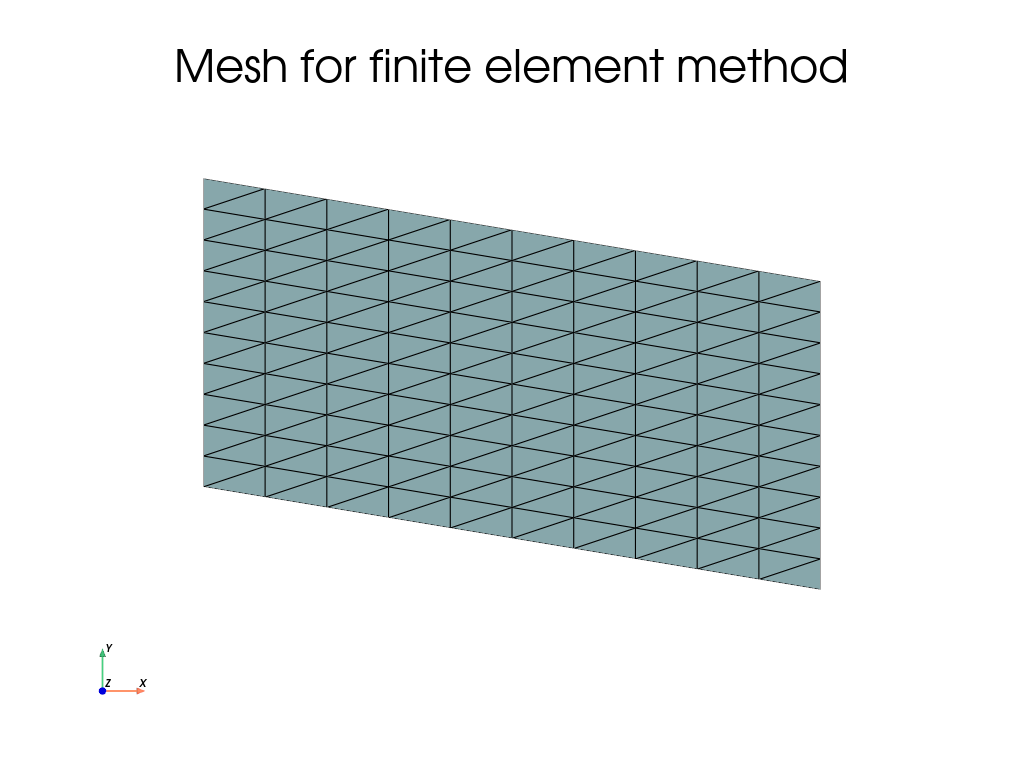

In [3]:
from visualization_fct import plot_mesh2
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 10, 10, P0, P1, P2, P3)
plot_mesh2(domain)

### Define variational problem

First try: two soils, loam underneath sand

In [4]:
# Define soil parameters for loam
alpha_1 = 3.6
N_1 = 1.56
theta_r_1 = 0.078
theta_s_1 = 0.43
Ks_1 = 2.89e-6

# Soil parameters for sand
alpha_2 = 14.5
N_2 = 2.68
theta_r_2 = 0.045
theta_s_2 = 0.43
Ks_2 = 8.25e-5

In [5]:
V = functionspace(domain, ("CG", 1))
v = TestFunction(V)
x = SpatialCoordinate(domain)

slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

In [6]:
def Saturation_1(u):
    eps = 1e-8
    u = conditional(u > eps, u, eps) # only use 'safe' values > 0
    a1 = 1 + exp(ln(alpha_1 * u)*N_1)
    exp1 = (1 - N_1) / N_1
    S = exp(ln(a1)*exp1)
    return S

def kr1(u):
    S = Saturation_1(u)
    m = N_1 / (N_1-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    k = sqrt(S) * a2 ** 2
    return k

def theta_1(u):
    S = Saturation_1(u)
    return S*(theta_s_1 - theta_r_1) + theta_r_1

def Saturation_2(u):
    eps = 1e-8
    u = conditional(u > eps, u, eps) # only use 'safe' values > 0
    a1 = 1 + exp(ln(alpha_2 * u)*N_2)
    exp1 = (1 - N_2) / N_2
    S = exp(ln(a1)*exp1)
    return S

def kr2(u):
    S = Saturation_2(u)
    m = N_1 / (N_2-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    k = sqrt(S) * a2 ** 2
    return k

def theta_2(u):
    S = Saturation_2(u)
    return S*(theta_s_2 - theta_r_2) + theta_r_2


### Define custom integration measures ds
Following https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html <br>
Define $\Gamma_{bed}$ to be boundary 1, $\Gamma_D$ boundary 2 (where we assume the groundwater table is at 0), $\Gamma_{out}$ is boundary 3 and $\Gamma_{in}$ boundary 4.

In [7]:
# Boundary conditions

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

In [8]:
boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

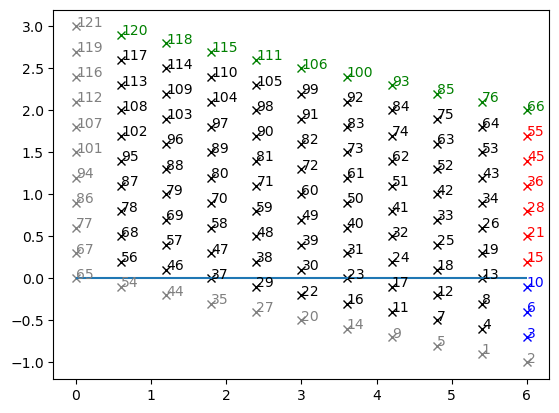

In [9]:
# Check, if the right boundaries are identified
pts = domain.geometry.x # mesh coordinates of the vertices shape=(num_points, 3)
pts = np.array(pts)
import matplotlib.pyplot as plt
for i, p in enumerate(pts):
    i += 1
    if gamma_bed(p):
        c = "grey"
    elif gamma_in(p):
        c = "green"
    elif gamma_out(p):
        c = "red"
    elif on_dirichlet(p):
        c = "blue"
    else:
        c = "black"
    plt.plot(p[0], p[1], 'x', color=c)
    plt.annotate(str(i), (p[0], p[1]), color=c)
plt.hlines(0, min(pts[:,0]), max(pts[:,0]))

In [10]:
# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

In [11]:
# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

In [12]:
# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [13]:
# Define boundary conditions
c_in = 2e-9 # recharge
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

In [14]:
bcs = []
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)

### Newton iteration

In [15]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

v = TestFunction(V)
uh = Function(V)
uh.interpolate(u_ini)
x = SpatialCoordinate(domain)
bc = bcs

F = inner(conditional(x[1]>= slope*x[0]+P3[1]/2, kr2(uh)*Ks_2, kr1(uh)*Ks_1)* grad(x[1] - uh), grad(v)) * dx - v*c_in*ds(4)
residual = form(F)
J = derivative(F, uh)
jacobian = form(J)

# Setup of iteration-independent structures
A = create_matrix(jacobian)
L = create_vector(extract_function_spaces(residual))

# Create linear solver and vector for delta_u
solver = PETSc.KSP().create(domain.comm)
solver.setType("preonly")
solver.getPC().setType("lu")
solver.getPC().setFactorSolverType("mumps")
solver.setErrorIfNotConverged(True)

solver.setOperators(A)
du = Function(V)


In [16]:
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    uh,
    bcs=bc,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)



uh = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)

  0 SNES Function norm 6.274182905583e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 6.274182905583e-06
    1 KSP Residual norm 4.237654902005e-21
  1 SNES Function norm 5.663197962389e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.663197962389e-06
    1 KSP Residual norm 7.374615839118e-21
  2 SNES Function norm 5.116405468640e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.116405468640e-06
    1 KSP Residual norm 2.869214851041e-20
  3 SNES Function norm 2.687664853998e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 2.687664853998e-06
    1 KSP Residual norm 9.445020967253e-21
  4 SNES Function norm 1.134588922829e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 1.134588922829e-06
    1 KSP Residual norm 9.265142631697e-22
  5 SNES Function norm 4.202356292676e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 4.202356292676e-07
    1 KSP R

### Plot solution

In [17]:
# Number of points along each edge
n = 10

# Create parameter space
x_int = np.linspace(0, 1, n)
y_int = np.linspace(0, 1, n)
x_int, y_int = np.meshgrid(x_int, y_int)

# Bilinear interpolation
x = (1 - x_int) * (1 - y_int) * P0[0] + x_int * (1 - y_int) * P1[0] + x_int * y_int * P2[0] + (1 - x_int) * y_int * P3[0]
y = (1 - x_int) * (1 - y_int) * P0[1] + x_int * (1 - y_int) * P1[1] + x_int * y_int * P2[1] + (1 - x_int) * y_int * P3[1]

# Combine into a grid of points
grid = np.column_stack((x.ravel(), y.ravel()))

# Evaluate u on grid
h = eval_fct_on_grid(grid, [uh], domain).reshape((n,n))
x = x.reshape((n,n))
z = y.reshape((n,n))


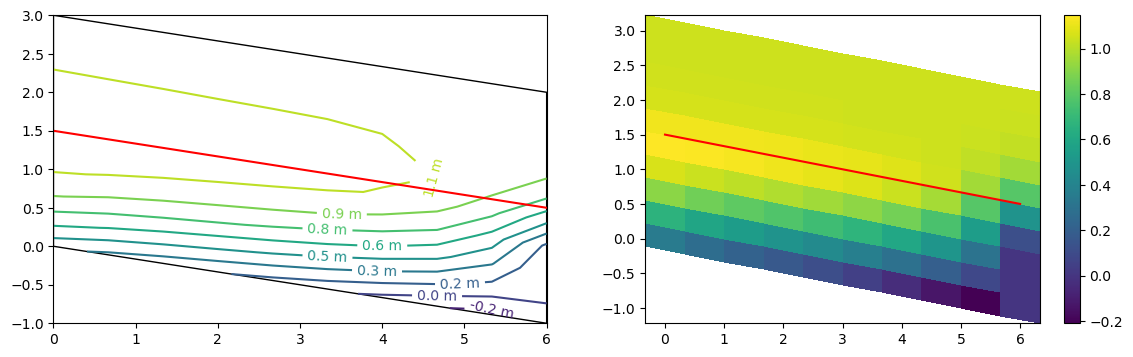

In [20]:
from matplotlib.patches import Polygon

fig, ax = plt.subplots(1,2, figsize=(14,4))
con = ax[0].contour(x, z, h, levels=10)
ax[0].clabel(con, fmt="%1.1f m")
# add black box around domain
polygon = Polygon([P1, P2, P3, P0], fill=False, edgecolor='black')
ax[0].add_patch(polygon)
# add line at layer interface
x_l = np.linspace(P0[0], P1[0], 100)
interface = slope*x_l+P3[1]/2
ax[0].plot(x_l, interface, color="red")

pmesh = ax[1].pcolormesh(x, z, h)
ax[1].plot(x_l, interface, color="red")
fig.colorbar(pmesh, ax = ax[1])



### Look at water retention curves

In [38]:
h_test = np.linspace(0, 3, 100)
def Saturation_sand(h_c):
    S = (1 + (alpha_2 * h_c)**N_2)**(1-1/N_2)
    return S

theta_sand = theta_r_2 + (theta_s_2 - theta_r_2)/Saturation_sand(h_test)

def Saturation_loam(h_c):
    S = (1 + (alpha_1 * h_c)**N_1)**(1-1/N_1)
    return S

theta_loam = theta_r_1 + (theta_s_1 - theta_r_1)/Saturation_loam(h_test)

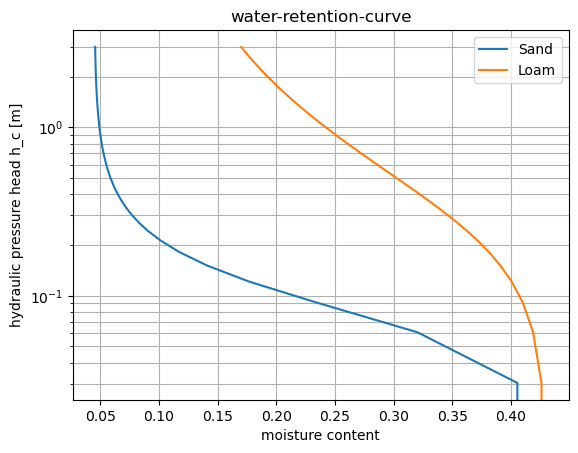

In [39]:
fig, ax = plt.subplots(1, 1)
ax.semilogy(theta_sand, h_test, label = "Sand")
ax.semilogy(theta_loam, h_test, label = "Loam")
ax.set_xlabel("moisture content")
ax.set_ylabel("hydraulic pressure head h_c [m]")
ax.set_title("water-retention-curve")
ax.grid(which="both")
ax.legend()
